# REHAB24 – TCN Training Notebook (Subject-wise Split)

This notebook trains a **Temporal Convolutional Network (TCN)** for **correct / incorrect** classification on the preprocessed REHAB24 dataset.

## Fixed subject-wise test set
- **person_id = 2**
- **person_id = 8**



## What this notebook does:
- Uses both **`X_pose.npy`** and **`X_angles.npy`**
- Uses a **residual dilated TCN**
- Uses a **train/validation split inside the training subjects only**
- Uses **standardization from training subjects only**
- Uses **early stopping**
- Saves the **best model**

## 1. Imports

In [61]:
import copy
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

## 2. Config

In [62]:
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_DIR = Path("artifacts/artifacts_rehab24_fullreps_F32")
OUT_DIR = Path("artifacts/tcn_subjectwise_6-2-2_BEST")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TEST_SUBJECTS = [2, 8]
VAL_SUBJECTS = [3, 7]

BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.50
PATIENCE = 10

# Synthetic data / augmentation
USE_DATA_SYNTHESIS = True
BALANCE_CLASSES_WITH_SYNTHESIS = True
NOISE_STD = 0.02
FEATURE_DROPOUT_P = 0.03
TEMPORAL_MASK_P = 0.20
MAX_SHIFT = 2

print("DEVICE:", DEVICE)
print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())
print("TEST_SUBJECTS:", TEST_SUBJECTS)
print("VAL_SUBJECTS:", VAL_SUBJECTS)
print("USE_DATA_SYNTHESIS:", USE_DATA_SYNTHESIS)
print("BALANCE_CLASSES_WITH_SYNTHESIS:", BALANCE_CLASSES_WITH_SYNTHESIS)


DEVICE: cuda
DATA_DIR: C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\classRehabV2\artifacts\artifacts_rehab24_fullreps_F32
OUT_DIR: C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\classRehabV2\artifacts\tcn_subjectwise_6-2-2_BEST
TEST_SUBJECTS: [2, 8]
VAL_SUBJECTS: [3, 7]
USE_DATA_SYNTHESIS: True
BALANCE_CLASSES_WITH_SYNTHESIS: True


## 3. Reproducibility

In [63]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

## 4. Load data

In [64]:
X_pose = np.load(DATA_DIR / "X_pose.npy")      # expected: (N, 32, 33, 10)
X_angles = np.load(DATA_DIR / "X_angles.npy")  # expected: (N, 32, 8)
y = np.load(DATA_DIR / "y.npy").astype(np.int64)
index_clean = pd.read_csv(DATA_DIR / "index_clean.csv")

print("X_pose:", X_pose.shape, X_pose.dtype)
print("X_angles:", X_angles.shape, X_angles.dtype)
print("y:", y.shape, y.dtype)
print("index_clean:", index_clean.shape)
index_clean.head()

X_pose: (1072, 32, 33, 10) float32
X_angles: (1072, 32, 8) float32
y: (1072,) int64
index_clean: (1072, 19)


,video_id,repetition_number,exercise_id,person_id,first_frame,last_frame,cam17_orientation,mocap_erroneous,exercise_subtype,lights_on,extra_person_in_cam17,extra_person_in_cam18,correctness,video_path_abs,pose_path,num_pose_frames,pose_shape,orig_num_pose_frames,fixed_num_pose_frames
0,PM_000,1,1,1,180,377,front,0,right arm,0,3,0,1,C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\d...,C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\c...,198,"(198, 33, 4)",198,32
1,PM_000,2,1,1,378,620,front,0,right arm,0,3,0,1,C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\d...,C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\c...,243,"(243, 33, 4)",243,32
2,PM_000,3,1,1,621,865,front,0,right arm,0,3,0,1,C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\d...,C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\c...,245,"(245, 33, 4)",245,32
3,PM_000,4,1,1,866,1085,front,0,right arm,0,3,3,1,C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\d...,C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\c...,220,"(220, 33, 4)",220,32
4,PM_000,5,1,1,1086,1265,front,0,right arm,0,3,3,1,C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\d...,C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\c...,180,"(180, 33, 4)",180,32


In [65]:
# Check how many times each subject appears
subject_counts = index_clean["person_id"].value_counts().sort_index()
print("Samples per subject:")
print(subject_counts)

subject_counts_df = subject_counts.reset_index()
subject_counts_df.columns = ["person_id", "num_samples"]
display(subject_counts_df)

Samples per subject:
person_id
1     123
2     116
3     123
4     115
5     117
6     106
7     115
8     122
9     127
10      8
Name: count, dtype: int64


,person_id,num_samples
0,1,123
1,2,116
2,3,123
3,4,115
4,5,117
5,6,106
6,7,115
7,8,122
8,9,127
9,10,8


In [66]:
# per-class counts for each subject
display(pd.crosstab(index_clean["person_id"], y, rownames=["person_id"], colnames=["label"]))

label,0,1
person_id,,
1,48,75
2,47,69
3,77,46
4,51,64
5,63,54
6,50,56
7,49,66
8,61,61
9,55,72


## 5. Build the model input

In [67]:
# Flatten joint features per frame, then concatenate angle features per frame.
# X_pose:   (N, T, 33, 10) -> (N, T, 330)
# X_angles: (N, T, 8)      -> (N, T, 8)
# Final:    (N, T, 338)

N, T, J, C = X_pose.shape
X_pose_flat = X_pose.reshape(N, T, J * C)
X_all = np.concatenate([X_pose_flat, X_angles], axis=-1).astype(np.float32)

print("Final input shape:", X_all.shape)  # (N, 32, 338)

Final input shape: (1072, 32, 338)


## 6. Subject-wise train / val / test split

In [68]:
# 6. Split: keep 2 subjects for test, remaining subjects for train+val

test_mask = index_clean["person_id"].isin(TEST_SUBJECTS).to_numpy()
trainval_mask = ~test_mask

X_trainval = X_all[trainval_mask]
y_trainval = y[trainval_mask]

X_test = X_all[test_mask]
y_test = y[test_mask]

idx_trainval = index_clean.loc[trainval_mask].reset_index(drop=True)
idx_test = index_clean.loc[test_mask].reset_index(drop=True)

print("Train+Val subjects:", sorted(idx_trainval["person_id"].unique()))
print("Test subjects:", sorted(idx_test["person_id"].unique()))
print()
print("Train+Val samples:", len(X_trainval))
print("Test samples:", len(X_test))

assert set(idx_test["person_id"].unique()) == set(TEST_SUBJECTS), "Test split is wrong!"
assert len(set(idx_trainval["person_id"].unique()) & set(TEST_SUBJECTS)) == 0, "Leakage between trainval and test!"

Train+Val subjects: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10)]
Test subjects: [np.int64(2), np.int64(8)]

Train+Val samples: 834
Test samples: 238


In [69]:
# Split train vs val by subjects
all_train_subjects = sorted(idx_trainval["person_id"].unique())
print("Available train subjects:", all_train_subjects)

assert len(set(VAL_SUBJECTS) & set(TEST_SUBJECTS)) == 0, "Val and Test overlap!"
assert set(VAL_SUBJECTS).issubset(set(all_train_subjects)), "Invalid VAL_SUBJECTS!"

train_subjects = [s for s in all_train_subjects if s not in VAL_SUBJECTS]

print("Train subjects:", train_subjects)
print("Val subjects:", VAL_SUBJECTS)

train_subj_mask = idx_trainval["person_id"].isin(train_subjects).to_numpy()
val_subj_mask = idx_trainval["person_id"].isin(VAL_SUBJECTS).to_numpy()

X_train = X_trainval[train_subj_mask]
y_train = y_trainval[train_subj_mask]

X_val = X_trainval[val_subj_mask]
y_val = y_trainval[val_subj_mask]

idx_train = idx_trainval.loc[train_subj_mask].reset_index(drop=True)
idx_val = idx_trainval.loc[val_subj_mask].reset_index(drop=True)

print("Train samples:", len(X_train))
print("Val samples:", len(X_val))
print("Test samples:", len(X_test))

print("\nTrain subject counts:")
print(idx_train["person_id"].value_counts().sort_index())

print("\nVal subject counts:")
print(idx_val["person_id"].value_counts().sort_index())

print("\nTest subject counts:")
print(idx_test["person_id"].value_counts().sort_index())

Available train subjects: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10)]
Train subjects: [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10)]
Val subjects: [3, 7]
Train samples: 596
Val samples: 238
Test samples: 238

Train subject counts:
person_id
1     123
4     115
5     117
6     106
9     127
10      8
Name: count, dtype: int64

Val subject counts:
person_id
3    123
7    115
Name: count, dtype: int64

Test subject counts:
person_id
2    116
8    122
Name: count, dtype: int64


## 7. Standardization from training split only

In [70]:
train_mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0, keepdims=True)
train_std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0, keepdims=True)
train_std = np.maximum(train_std, 1e-6)

def apply_standardization(X, mean, std):
    return ((X - mean) / std).astype(np.float32)

X_train = apply_standardization(X_train, train_mean, train_std)
X_val = apply_standardization(X_val, train_mean, train_std)
X_test = apply_standardization(X_test, train_mean, train_std)

print("Standardized shapes:", X_train.shape, X_val.shape, X_test.shape)

Standardized shapes: (596, 32, 338) (238, 32, 338) (238, 32, 338)


## 8. Data synthesis for the training set

To reduce overfitting and help the model generalize across subjects, we create **synthetic training samples online** only for the training split.

The idea is:
- keep **validation and test unchanged**
- duplicate minority-class training samples to balance the classes
- apply small sequence-preserving perturbations such as:
  - Gaussian noise
  - small temporal shifts
  - temporal masking
  - feature dropout

This is safer than changing labels or synthesizing validation/test data, and it works well for pose-sequence classification.

In [71]:
train_class_counts = pd.Series(y_train).value_counts().sort_index()
val_class_counts = pd.Series(y_val).value_counts().sort_index()
test_class_counts = pd.Series(y_test).value_counts().sort_index()

print("Train class counts:")
print(train_class_counts)
print("\nVal class counts:")
print(val_class_counts)
print("\nTest class counts:")
print(test_class_counts)

def build_training_index(y_train, balance_classes=True, seed=42):
    rng = np.random.default_rng(seed)
    y_train = np.asarray(y_train)
    index_flags = [(i, False) for i in range(len(y_train))]

    if not balance_classes:
        rng.shuffle(index_flags)
        return index_flags

    class_to_idx = {cls: np.where(y_train == cls)[0] for cls in np.unique(y_train)}
    max_count = max(len(v) for v in class_to_idx.values())

    for cls, idxs in class_to_idx.items():
        deficit = max_count - len(idxs)
        if deficit > 0:
            extra = rng.choice(idxs, size=deficit, replace=True)
            index_flags.extend((int(i), True) for i in extra)

    rng.shuffle(index_flags)
    return index_flags

train_index_flags = build_training_index(
    y_train,
    balance_classes=USE_DATA_SYNTHESIS and BALANCE_CLASSES_WITH_SYNTHESIS,
    seed=SEED,
)

synth_train_size = sum(int(is_synth) for _, is_synth in train_index_flags)

print(f"Original train size: {len(X_train)}")
print(f"Training size after synthesis indexing: {len(train_index_flags)}")
print(f"Number of synthetic/augmented draws per epoch: {synth_train_size}")


Train class counts:
0    270
1    326
Name: count, dtype: int64

Val class counts:
0    126
1    112
Name: count, dtype: int64

Test class counts:
0    108
1    130
Name: count, dtype: int64
Original train size: 596
Training size after synthesis indexing: 652
Number of synthetic/augmented draws per epoch: 56


## 8. Dataset and DataLoaders

In [72]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx].transpose(1, 0), dtype=torch.float32)  # (T, F) -> (F, T)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


class SynthSequenceDataset(Dataset):
    def __init__(
        self,
        X,
        y,
        index_flags,
        noise_std=0.02,
        feature_dropout_p=0.03,
        temporal_mask_p=0.20,
        max_shift=2,
    ):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.int64)
        self.index_flags = list(index_flags)
        self.noise_std = float(noise_std)
        self.feature_dropout_p = float(feature_dropout_p)
        self.temporal_mask_p = float(temporal_mask_p)
        self.max_shift = int(max_shift)

    def __len__(self):
        return len(self.index_flags)

    def _augment(self, x):
        x = x.copy()  # (T, F)

        # small temporal shift
        if self.max_shift > 0:
            shift = np.random.randint(-self.max_shift, self.max_shift + 1)
            if shift != 0:
                x = np.roll(x, shift=shift, axis=0)

        # gaussian noise
        if self.noise_std > 0:
            x = x + np.random.normal(0.0, self.noise_std, size=x.shape).astype(np.float32)

        # feature dropout
        if self.feature_dropout_p > 0:
            feat_mask = (np.random.rand(1, x.shape[1]) > self.feature_dropout_p).astype(np.float32)
            x = x * feat_mask

        # temporal masking (drop a short contiguous chunk)
        if self.temporal_mask_p > 0 and np.random.rand() < self.temporal_mask_p:
            T = x.shape[0]
            mask_len = max(1, T // 8)
            start = np.random.randint(0, max(1, T - mask_len + 1))
            x[start:start + mask_len] = 0.0

        return x.astype(np.float32)

    def __getitem__(self, idx):
        base_idx, is_synth = self.index_flags[idx]
        x = self.X[base_idx]
        y = self.y[base_idx]

        if is_synth:
            x = self._augment(x)

        x = torch.tensor(x.transpose(1, 0), dtype=torch.float32)  # (T, F) -> (F, T)
        y = torch.tensor(y, dtype=torch.long)
        return x, y


if USE_DATA_SYNTHESIS:
    train_ds = SynthSequenceDataset(
        X_train,
        y_train,
        train_index_flags,
        noise_std=NOISE_STD,
        feature_dropout_p=FEATURE_DROPOUT_P,
        temporal_mask_p=TEMPORAL_MASK_P,
        max_shift=MAX_SHIFT,
    )
else:
    train_ds = SequenceDataset(X_train, y_train)

val_ds = SequenceDataset(X_val, y_val)
test_ds = SequenceDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, pin_memory=True)

xb, yb = next(iter(train_loader))
print("Train batch X:", xb.shape)
print("Train batch y:", yb.shape)

Train batch X: torch.Size([32, 338, 32])
Train batch y: torch.Size([32])


## 9. Residual TCN

In [73]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x if self.chomp_size == 0 else x[:, :, :-self.chomp_size]


class ResidualTCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.5):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()
        self.out_relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.net(x)
        res = self.downsample(x)
        return self.out_relu(out + res)


class TCNClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout=0.5):
        super().__init__()
        self.backbone = nn.Sequential(
            ResidualTCNBlock(input_dim, 64, kernel_size=3, dilation=1, dropout=dropout),
            ResidualTCNBlock(64, 64, kernel_size=3, dilation=2, dropout=dropout),
            ResidualTCNBlock(64, 96, kernel_size=3, dilation=4, dropout=dropout),
            ResidualTCNBlock(96, 96, kernel_size=3, dilation=8, dropout=dropout),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = self.head(x)
        return x

## 10. Initialize training

In [74]:
input_dim = X_train.shape[-1]
num_classes = len(np.unique(y))

model = TCNClassifier(input_dim=input_dim, num_classes=num_classes, dropout=DROPOUT).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

TCNClassifier(
  (backbone): Sequential(
    (0): ResidualTCNBlock(
      (net): Sequential(
        (0): Conv1d(338, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (1): Chomp1d()
        (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU(inplace=True)
        (4): Dropout(p=0.5, inplace=False)
        (5): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (6): Chomp1d()
        (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): ReLU(inplace=True)
        (9): Dropout(p=0.5, inplace=False)
      )
      (downsample): Conv1d(338, 64, kernel_size=(1,), stride=(1,))
      (out_relu): ReLU(inplace=True)
    )
    (1): ResidualTCNBlock(
      (net): Sequential(
        (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (1): Chomp1d()
        (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

## 11. Train / evaluate helpers

In [75]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    all_preds = []
    all_targets = []

    for x, target in loader:
        x = x.to(DEVICE, non_blocking=True)
        target = target.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = criterion(logits, target)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        losses.append(loss.item())
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(target.detach().cpu().numpy().tolist())

    loss_mean = float(np.mean(losses))
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")
    return loss_mean, acc, f1, np.array(all_targets), np.array(all_preds)

## 12. Training loop with early stopping

In [76]:
history = []
best_val_f1 = -1.0
best_state = None
best_epoch = -1
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_f1, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(val_f1)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

history_df = pd.DataFrame(history)
history_df.tail()

Epoch 001 | train_loss=0.7101 train_acc=0.5337 train_f1=0.5331 | val_loss=0.6752 val_acc=0.5798 val_f1=0.5768
Epoch 002 | train_loss=0.6786 train_acc=0.5613 train_f1=0.5599 | val_loss=0.6547 val_acc=0.5966 val_f1=0.5959
Epoch 003 | train_loss=0.6409 train_acc=0.6104 train_f1=0.6056 | val_loss=0.6177 val_acc=0.6681 val_f1=0.6589
Epoch 004 | train_loss=0.6289 train_acc=0.6411 train_f1=0.6386 | val_loss=0.6174 val_acc=0.6597 val_f1=0.6530
Epoch 005 | train_loss=0.6048 train_acc=0.6887 train_f1=0.6884 | val_loss=0.7110 val_acc=0.6050 val_f1=0.5987
Epoch 006 | train_loss=0.5561 train_acc=0.7285 train_f1=0.7277 | val_loss=0.6576 val_acc=0.6723 val_f1=0.6722
Epoch 007 | train_loss=0.5312 train_acc=0.7807 train_f1=0.7806 | val_loss=0.8810 val_acc=0.6092 val_f1=0.5985
Epoch 008 | train_loss=0.4406 train_acc=0.8359 train_f1=0.8359 | val_loss=0.8862 val_acc=0.6555 val_f1=0.6525
Epoch 009 | train_loss=0.5023 train_acc=0.8144 train_f1=0.8132 | val_loss=1.0920 val_acc=0.6765 val_f1=0.6537
Epoch 010 

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,lr
19,20,0.321792,0.937117,0.937113,0.895330,0.726891,0.717675,0.00050
20,21,0.312957,0.938650,0.938648,0.881030,0.726891,0.720127,0.00050
21,22,0.304223,0.955521,0.955521,0.893799,0.726891,0.720854,0.00025
22,23,0.298202,0.958589,0.958584,0.881021,0.701681,0.696532,0.00025
23,24,0.288158,0.963190,0.963189,0.932414,0.722689,0.713776,0.00025


## 13. Load best model

In [77]:
model.load_state_dict(best_state)

best_model_path = OUT_DIR / "best_tcn_subjectwise6-2-2.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "train_mean": train_mean,
    "train_std": train_std,
    "test_subjects": TEST_SUBJECTS,
    "trainval_subjects": sorted(idx_trainval["person_id"].unique().tolist()),
    "input_dim": input_dim,
}, best_model_path)

print("Best epoch:", best_epoch)
print("Best val macro-F1:", best_val_f1)
print("Saved model:", best_model_path.resolve())

Best epoch: 14
Best val macro-F1: 0.7466211948970569
Saved model: C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\classRehabV2\artifacts\tcn_subjectwise_6-2-2_BEST\best_tcn_subjectwise6-2-2.pt


## 14. Test evaluation

In [78]:
test_loss, test_acc, test_f1, y_true, y_pred = run_epoch(model, test_loader, criterion, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))
print("Test macro-F1:", round(test_f1, 4))
print()
print(classification_report(y_true, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

Test loss: 0.9062
Test accuracy: 0.7647
Test macro-F1: 0.7641

              precision    recall  f1-score   support

           0     0.7203    0.7870    0.7522       108
           1     0.8083    0.7462    0.7760       130

    accuracy                         0.7647       238
   macro avg     0.7643    0.7666    0.7641       238
weighted avg     0.7684    0.7647    0.7652       238

Confusion matrix:
[[85 23]
 [33 97]]


## 15. Save training report

In [79]:
report = {
    "test_subjects": TEST_SUBJECTS,
    "trainval_subjects": sorted(idx_trainval["person_id"].unique().tolist()),
    "best_epoch": int(best_epoch),
    "best_val_macro_f1": float(best_val_f1),
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_f1),
    "n_train": int(len(X_train)),
    "n_val": int(len(X_val)),
    "n_test": int(len(X_test)),
}

report_path = OUT_DIR / "training_report.json"
history_path = OUT_DIR / "history.csv"

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

history_df.to_csv(history_path, index=False)

print("Saved report:", report_path.resolve())
print("Saved history:", history_path.resolve())
report

Saved report: C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\classRehabV2\artifacts\tcn_subjectwise_6-2-2_BEST\training_report.json
Saved history: C:\Users\nadaf\Desktop\DS+Code\Rehab24-class\classRehabV2\artifacts\tcn_subjectwise_6-2-2_BEST\history.csv


{'test_subjects': [2, 8],
 'trainval_subjects': [1, 3, 4, 5, 6, 7, 9, 10],
 'best_epoch': 14,
 'best_val_macro_f1': 0.7466211948970569,
 'test_accuracy': 0.7647058823529411,
 'test_macro_f1': 0.7641061946902654,
 'n_train': 596,
 'n_val': 238,
 'n_test': 238}

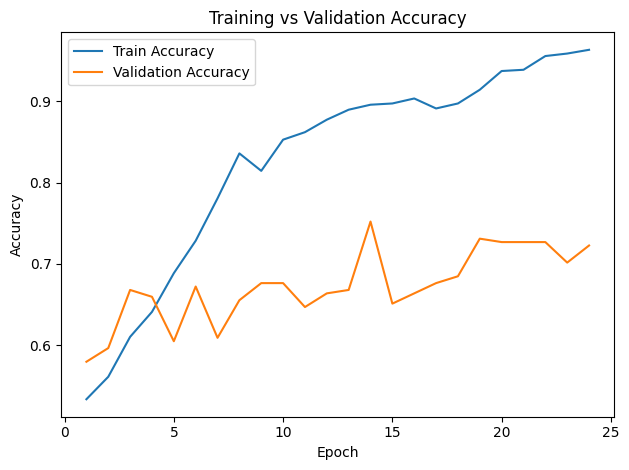

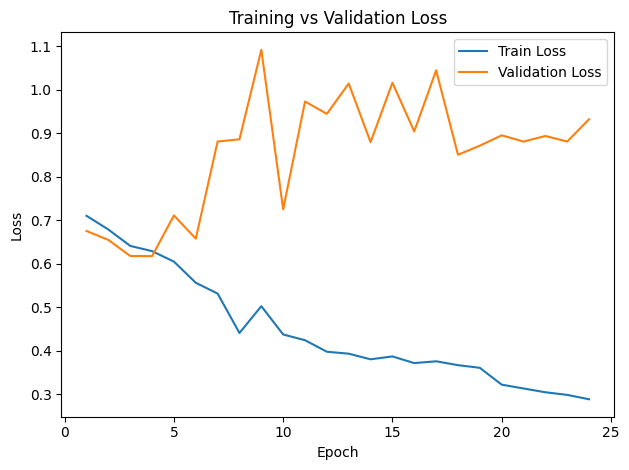

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv("artifacts/tcn_subjectwise_6-2-2_BEST\history.csv")

plt.figure()
plt.plot(history["epoch"], history["train_acc"], label="Train Accuracy")
plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

plt.figure()
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()